# 01 - Basic scaling analysis

Input:

- `analysis_output/preprocessed_core_data.csv`

Outputs:

- `analysis_output/basic_scaling.csv`
- `analysis_output/basic_scaling_runtime.png`
- `analysis_output/basic_scaling_speedup.png`
- `analysis_output/basic_scaling_efficiency.png`

This notebook computes:

- mean runtime per process count
- speedup against the smallest measured process count
- efficiency
- B&B nodes per second


In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SOURCE = "newest"
OUTPUT_DIR = Path("analysis_output")
INPUT_CSV = OUTPUT_DIR / f"preprocessed_data_{SOURCE}.csv"

df = pd.read_csv(INPUT_CSV)
display(df.head())


,source,workers,cores,time_s,bab_nodes
0,newest_solutions,7,8,1234.405245,17757
1,newest_solutions,15,16,592.235753,17811
2,newest_solutions,63,64,147.406386,17761
3,newest_solutions,127,128,75.849920,17729
4,newest_solutions,255,256,46.394310,17813


In [18]:
agg = (
    df.groupby(["workers", "cores"], as_index=False)
    .agg(
        runs=("time_s", "size"),
        time_mean_s=("time_s", "mean"),
        time_std_s=("time_s", "std"),
        time_min_s=("time_s", "min"),
        time_max_s=("time_s", "max"),
        bab_nodes_mean=("bab_nodes", "mean"),
        bab_nodes_std=("bab_nodes", "std"),
    )
    .sort_values("cores")
    .reset_index(drop=True)
)

baseline = agg.iloc[0]
baseline_cores = baseline["cores"]
baseline_time = baseline["time_mean_s"]

agg["speedup"] = baseline_time / agg["time_mean_s"]
agg["ideal_speedup"] = agg["cores"] / baseline_cores
agg["efficiency"] = agg["speedup"] / agg["ideal_speedup"]
agg["bab_nodes_per_second"] = agg["bab_nodes_mean"] / agg["time_mean_s"]

display(agg)

out = OUTPUT_DIR / f"basic_scaling_{SOURCE}.csv"
agg.to_csv(out, index=False)
print(f"Saved: {out}")


,workers,cores,runs,time_mean_s,time_std_s,time_min_s,time_max_s,bab_nodes_mean,bab_nodes_std,speedup,ideal_speedup,efficiency,bab_nodes_per_second
0,7,8,1,1234.405245,NaN,1234.405245,1234.405245,17757.0,NaN,1.000000,1.0,1.000000,14.385065
1,15,16,1,592.235753,NaN,592.235753,592.235753,17811.0,NaN,2.084314,2.0,1.042157,30.074172
2,63,64,1,147.406386,NaN,147.406386,147.406386,17761.0,NaN,8.374164,8.0,1.046770,120.490031
3,127,128,1,75.849920,NaN,75.849920,75.849920,17729.0,NaN,16.274312,16.0,1.017144,233.737887
4,255,256,1,46.394310,NaN,46.394310,46.394310,17813.0,NaN,26.606824,32.0,0.831463,383.947947
5,511,512,1,28.819229,NaN,28.819229,28.819229,17735.0,NaN,42.832695,64.0,0.669261,615.387734
6,1023,1024,1,16.589059,NaN,16.589059,16.589059,17829.0,NaN,74.410806,128.0,0.581334,1074.744509


Saved: analysis_output/basic_scaling_newest.csv


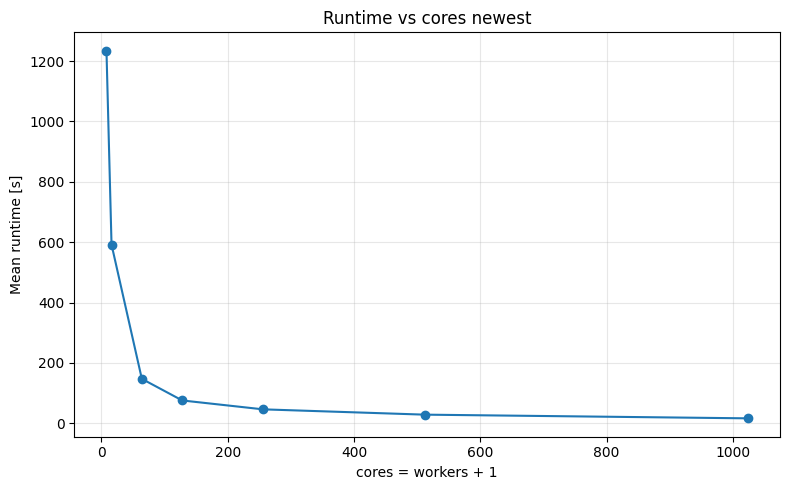

Saved: analysis_output/basic_scaling_runtimenewest.png


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(agg["cores"], agg["time_mean_s"], marker="o")
plt.xlabel("cores = workers + 1")
plt.ylabel("Mean runtime [s]")
plt.title(F"Runtime vs cores {SOURCE}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
out = OUTPUT_DIR / f"basic_scaling_runtime_{SOURCE}.png"
plt.savefig(out, dpi=160)
plt.show()
print(f"Saved: {out}")


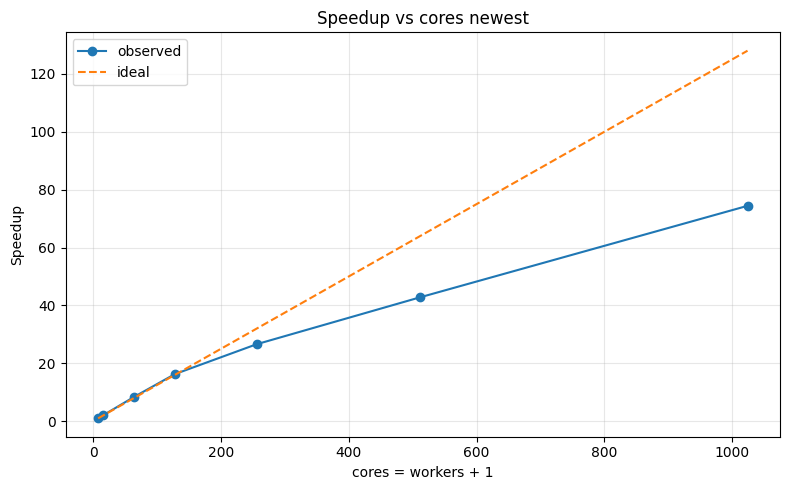

Saved: analysis_output/basic_scaling_speedup_newest.png


In [20]:
plt.figure(figsize=(8, 5))
plt.plot(agg["cores"], agg["speedup"], marker="o", label="observed")
plt.plot(agg["cores"], agg["ideal_speedup"], linestyle="--", label="ideal")
plt.xlabel("cores = workers + 1")
plt.ylabel("Speedup")
plt.title(F"Speedup vs cores {SOURCE}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
out = OUTPUT_DIR / F"basic_scaling_speedup_{SOURCE}.png"
plt.savefig(out, dpi=160)
plt.show()
print(f"Saved: {out}")


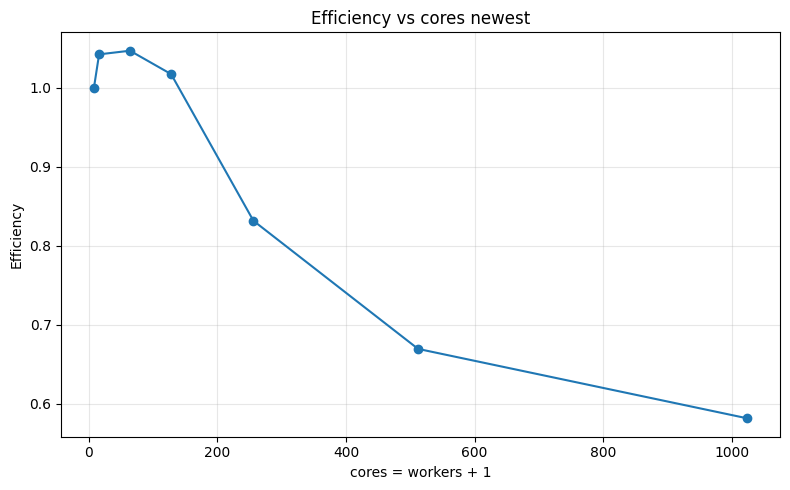

Saved: analysis_output/basic_scaling_efficiency_newest.png


In [21]:
plt.figure(figsize=(8, 5))
plt.plot(agg["cores"], agg["efficiency"], marker="o")
plt.xlabel("cores = workers + 1")
plt.ylabel("Efficiency")
plt.title(f"Efficiency vs cores {SOURCE}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
out = OUTPUT_DIR / f"basic_scaling_efficiency_{SOURCE}.png"
plt.savefig(out, dpi=160)
plt.show()
print(f"Saved: {out}")
